In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sparrow import Protein
from tqdm import tqdm
from collections import defaultdict
import re


plt.rcParams['svg.fonttype'] = 'none'

In [2]:
WTCRX = 'MMAYMNPGPHYSVNALALSGPSVDLMHQAVPYPSAPRKQRRERTTFTRSQLEELEALFAKTQYPDVYAREEVALKINLPESRVQVWFKNRRAKCRQQRQQQKQQQQPPGGQAKARPAKRKAGTSPRPSTDVCPDPLGISDSYSPPLPGPSGSPTTAVATVSIWSPASESPLPEAQRAGLVASGPSLTSAPYAMTYAPASAFCSSPSAYGSPSSYFSGLDPYLSPMVPQLGGPALSPLSGPSVGPSLAQSPTSLSGQSYGAYSPVDSLEFKDPTGTWKFTYNPMDPLDYKDQSAWKFQIL'

In [3]:
p = Protein(WTCRX)

test = pd.DataFrame([
    {
        'identifier':           elm.identifier,
        'functional_site_name': elm.functional_site_name,
        'description':          elm.description,
        'probability':          float(elm.probability),
        'regex':                elm.regex,
        'start':                int(elm.start),
        'end':                  int(elm.end),
        'sequence':             elm.sequence,
    }
    for elm in p.elms
]).sort_values('start').reset_index(drop=True)

print(test.shape)
test

(139, 8)


,identifier,functional_site_name,description,probability,regex,start,end,sequence
0,LIG_SH2_CRK,Phosphotyrosine ligands bound by SH2 domains,CRK family SH2 domain binding motif.,0.001515,(Y)[^EPILVFYW][^HDEW][PLIV][^DEW],3,8,YMNPG
1,LIG_SH2_GRB2like,Phosphotyrosine ligands bound by SH2 domains,GRB2-like Src Homology 2 (SH2) domains binding...,0.000317,(Y)([EDST]|[MLIVAFYHQW])N.,3,7,YMNP
2,LIG_Arc_Nlobe_1,Arc N-lobe binding ligand,Binding motif for the N-lobe part of the C-ter...,0.004385,"[^P][P]G{0,1}[^P][YFH][^P]",7,12,GPHYS
3,LIG_SH2_STAP1,Phosphotyrosine ligands bound by SH2 domains,STAP1 Src Homology 2 (SH2) domain Class 2 bind...,0.001026,(Y)[DESTA][^GP][^GP][ILVFMWYA],10,15,YSVNA
4,LIG_IRF7_LxLS_2,IRF interaction and dimerisation motifs,A binding site for IRF-7 present in the protei...,0.000486,"[VILPFYM].{1,3}L.L(S)",12,19,VNALALS
...,...,...,...,...,...,...,...,...
134,LIG_SH3_3,SH3 domain ligands,This is the motif recognized by those SH3 doma...,0.013173,...[PV]..P,278,285,TYNPMDP
135,TRG_ENDOCYTIC_2,Y-based sorting signal,Tyrosine-based sorting signal responsible for ...,0.002587,Y..[LMVIF],279,283,YNPM
136,LIG_SH2_STAT3,Phosphotyrosine ligands bound by SH2 domains,YXXQ motif found in the cytoplasmic region of ...,0.000797,(Y)..Q,287,291,YKDQ
137,MOD_Plk_1,Polo-like kinase phosphosites,Ser/Thr residue phosphorylated by the Plk1 kinase,0.007674,.[DNE][^PG][ST](([FYILMVW]..)|([^PEDGKN][FWYLI...,288,295,KDQSAWK


In [4]:
AAS = list('ACDEFGHIKLMNPQRSTVWY')

rows = []
for pos, wt_aa in enumerate(WTCRX):
    for mut_aa in AAS:
        if mut_aa == wt_aa:
            continue
        mutation = f'{wt_aa}{pos + 1}{mut_aa}'   # 1-indexed
        sequence = WTCRX[:pos] + mut_aa + WTCRX[pos + 1:]
        rows.append({'mutation': mutation, 'sequence': sequence})
df_mutations = pd.DataFrame(rows)

In [5]:
CATEGORIES = ['CLV', 'DEG', 'DOC', 'LIG', 'MOD', 'TRG']

def canonical_elm_id(identifier):
    """
    Collapse trailing numeric variant so e.g.
    DOC_SH2_1_2 and DOC_SH2_1_1 -> DOC_SH2_1
    """
    return re.sub(r'_\d+$', '', identifier)

def resolve_overlaps(entries):
    """
    entries: list of dicts with keys: id, start, end
    For overlapping intervals of the same id:
      - keep largest span (end-start)
      - if tie, keep earliest start
    """
    if not entries:
        return []

    entries = sorted(entries, key=lambda x: (x['start'], x['end']))
    kept = []

    cluster = [entries[0]]
    cluster_max_end = entries[0]['end']

    def pick_best(cluster_entries):
        # largest span first, then earliest start
        return sorted(
            cluster_entries,
            key=lambda x: (-(x['end'] - x['start']), x['start'])
        )[0]

    for e in entries[1:]:
        if e['start'] <= cluster_max_end:  # overlap with current cluster
            cluster.append(e)
            cluster_max_end = max(cluster_max_end, e['end'])
        else:
            kept.append(pick_best(cluster))
            cluster = [e]
            cluster_max_end = e['end']

    kept.append(pick_best(cluster))
    return kept

def get_elm_set(sequence):
    """
    Return set of unique normalized ELM identifiers with position appended:
      CANONICAL_IDENTIFIER_start-end
    with overlap-resolved hits per canonical identifier.
    """
    p = Protein(sequence)

    grouped = defaultdict(list)
    for elm in p.elms:
        cid = canonical_elm_id(elm.identifier)
        grouped[cid].append({
            'id': cid,
            'start': int(elm.start),
            'end': int(elm.end),
        })

    resolved = []
    for cid, entries in grouped.items():
        resolved.extend(resolve_overlaps(entries))

    return set(f"{e['id']}_{e['start']}-{e['end']}" for e in resolved)

def count_by_category(elm_set):
    counts = {cat: 0 for cat in CATEGORIES}
    for uid in elm_set:
        cat = uid.split('_')[0]
        if cat in counts:
            counts[cat] += 1
    return counts

def locations_by_category(elm_set):
    """Return dict of category -> sorted list of 'start-end' strings"""
    locs = {cat: [] for cat in CATEGORIES}
    for uid in elm_set:
        cat = uid.split('_')[0]
        if cat in locs:
            pos = uid.rsplit('_', 1)[-1]
            locs[cat].append(pos)
    return {cat: sorted(v) for cat, v in locs.items()}

def which_locations_by_category(elm_set):
    """Return dict of category -> sorted list of full 'IDENTIFIER_start-end' strings"""
    which = {cat: [] for cat in CATEGORIES}
    for uid in elm_set:
        cat = uid.split('_')[0]
        if cat in which:
            which[cat].append(uid)          # uid already = e.g. MOD_GLYC1_2_151-190
    return {cat: sorted(v) for cat, v in which.items()}



In [ ]:
# ── Version WITHOUT canonical collapsing ─────────────────────────────────────
def get_elm_set_raw(sequence):
    """Same as get_elm_set but keeps the original identifier (no _N suffix strip)."""
    p = Protein(sequence)
    grouped = defaultdict(list)
    for elm in p.elms:
        grouped[elm.identifier].append({   # raw identifier, not collapsed
            'id': elm.identifier,
            'start': int(elm.start),
            'end': int(elm.end),
        })
    resolved = []
    for ident, entries in grouped.items():
        resolved.extend(resolve_overlaps(entries))
    return set(f"{e['id']}_{e['start']}-{e['end']}" for e in resolved)

100%|██████████| 1000/1000 [00:17<00:00, 58.52it/s]


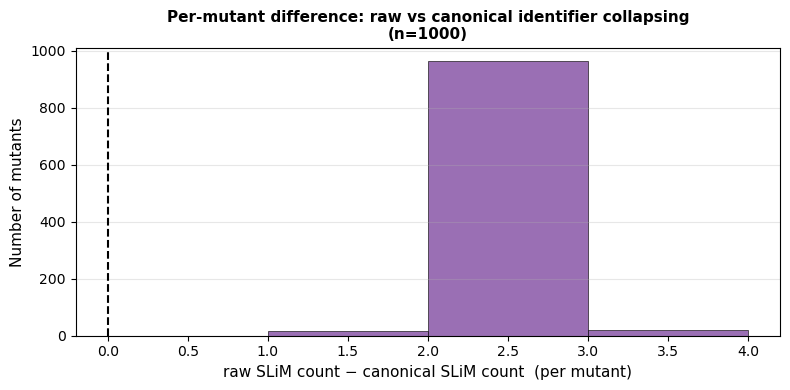

All zero (no effect):    0 / 1000
Raw has more:            1000
Canonical has more:      0
Max difference:          3


In [7]:
sample = df_mutations.sample(1000, random_state=42)

per_mutant_diff = []

for _, row in tqdm(sample.iterrows(), total=len(sample)):
    seq = row['sequence']
    n_canonical = len(get_elm_set(seq))
    n_raw       = len(get_elm_set_raw(seq))
    per_mutant_diff.append(n_raw - n_canonical)   # positive = raw has more

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_mutant_diff, bins=range(min(per_mutant_diff)-1, max(per_mutant_diff)+2),
        color='#8856a7', edgecolor='black', linewidth=0.5, alpha=0.85)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('raw SLiM count − canonical SLiM count  (per mutant)', fontsize=11)
ax.set_ylabel('Number of mutants', fontsize=11)
ax.set_title('Per-mutant difference: raw vs canonical identifier collapsing\n(n=1000)',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"All zero (no effect):    {sum(d==0 for d in per_mutant_diff)} / {len(per_mutant_diff)}")
print(f"Raw has more:            {sum(d>0 for d in per_mutant_diff)}")
print(f"Canonical has more:      {sum(d<0 for d in per_mutant_diff)}")
print(f"Max difference:          {max(per_mutant_diff)}")

In [9]:
from collections import Counter

collapsed_slims = Counter()   # which canonical IDs are involved in collapsing
example_pairs   = []          # (raw_uid, canonical_uid) examples

for _, row in tqdm(sample.iterrows(), total=len(sample)):
    seq = row['sequence']
    raw_set       = get_elm_set_raw(seq)
    canonical_set = get_elm_set(seq)

    # UIDs in raw but not canonical = the ones that got removed/merged
    removed_by_collapsing = raw_set - canonical_set

    for uid in removed_by_collapsing:
        # uid format: IDENTIFIER_start-end  (raw, so e.g. DOC_SH2_1_2_45-60)
        loc   = uid.rsplit('_', 1)[-1]          # '45-60'
        ident = uid.rsplit('_', 1)[0]           # 'DOC_SH2_1_2'
        canon = canonical_elm_id(ident)         # 'DOC_SH2_1'
        collapsed_slims[ident] += 1
        if len(example_pairs) < 20:
            example_pairs.append((uid, f'{canon}_{loc}'))

print("=== Raw identifiers removed by canonical_elm_id (most common first) ===")
for ident, count in collapsed_slims.most_common():
    print(f"  {ident:40s}  collapsed to: {canonical_elm_id(ident):35s}  (seen in {count} mutants)")

print(f"\n=== First {len(example_pairs)} examples (raw → canonical) ===")
for raw, canon in example_pairs:
    print(f"  {raw}  →  {canon}")

100%|██████████| 1000/1000 [00:17<00:00, 58.28it/s]

=== Raw identifiers removed by canonical_elm_id (most common first) ===
  LIG_WD40_WDR5_VDV_2                       collapsed to: LIG_WD40_WDR5_VDV                    (seen in 10949 mutants)
  DOC_WW_Pin1_4                             collapsed to: DOC_WW_Pin1                          (seen in 8978 mutants)
  MOD_ProDKin_1                             collapsed to: MOD_ProDKin                          (seen in 8978 mutants)
  MOD_GSK3_1                                collapsed to: MOD_GSK3                             (seen in 8961 mutants)
  MOD_CK1_1                                 collapsed to: MOD_CK1                              (seen in 6996 mutants)
  DOC_USP7_MATH_1                           collapsed to: DOC_USP7_MATH                        (seen in 5978 mutants)
  LIG_SH3_3                                 collapsed to: LIG_SH3                              (seen in 3995 mutants)
  LIG_LIR_Apic_2                            collapsed to: LIG_LIR_Apic                         (seen 

100%|██████████| 1000/1000 [00:17<00:00, 55.85it/s]


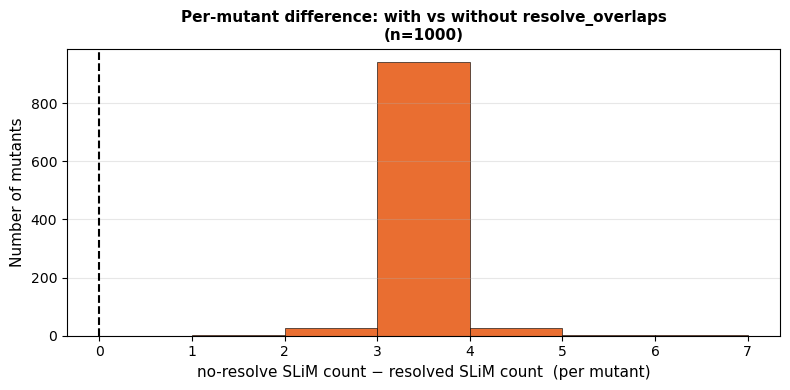

All zero (no effect):         0 / 1000
No-resolve has more SLiMs:    1000
Resolved has more SLiMs:      0
Max difference:               6
Mean difference:              3.004


In [8]:
# ── Version WITHOUT resolve_overlaps ─────────────────────────────────────────
def get_elm_set_no_resolve(sequence):
    """Same as get_elm_set but skips overlap resolution — keeps all hits."""
    p = Protein(sequence)
    grouped = defaultdict(list)
    for elm in p.elms:
        cid = canonical_elm_id(elm.identifier)
        grouped[cid].append({
            'id': cid,
            'start': int(elm.start),
            'end': int(elm.end),
        })
    # No resolve_overlaps — just flatten all entries
    resolved = [e for entries in grouped.values() for e in entries]
    return set(f"{e['id']}_{e['start']}-{e['end']}" for e in resolved)

sample = df_mutations.sample(1000, random_state=42)

per_mutant_diff = []

for _, row in tqdm(sample.iterrows(), total=len(sample)):
    seq = row['sequence']
    n_resolved    = len(get_elm_set(seq))            # with resolve_overlaps
    n_no_resolved = len(get_elm_set_no_resolve(seq)) # without
    per_mutant_diff.append(n_no_resolved - n_resolved)  # positive = no_resolve has more

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_mutant_diff, bins=range(min(per_mutant_diff)-1, max(per_mutant_diff)+2),
        color='#e6550d', edgecolor='black', linewidth=0.5, alpha=0.85)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('no-resolve SLiM count − resolved SLiM count  (per mutant)', fontsize=11)
ax.set_ylabel('Number of mutants', fontsize=11)
ax.set_title('Per-mutant difference: with vs without resolve_overlaps\n(n=1000)',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"All zero (no effect):         {sum(d==0 for d in per_mutant_diff)} / {len(per_mutant_diff)}")
print(f"No-resolve has more SLiMs:    {sum(d>0 for d in per_mutant_diff)}")
print(f"Resolved has more SLiMs:      {sum(d<0 for d in per_mutant_diff)}")
print(f"Max difference:               {max(per_mutant_diff)}")
print(f"Mean difference:              {np.mean(per_mutant_diff):.3f}")

In [10]:
from collections import Counter

removed_by_resolve = Counter()
example_pairs = []

for _, row in tqdm(sample.iterrows(), total=len(sample)):
    seq = row['sequence']
    no_resolve_set = get_elm_set_no_resolve(seq)
    resolved_set   = get_elm_set(seq)

    # UIDs present when NOT resolving but gone after resolving = removed by overlap resolution
    removed = no_resolve_set - resolved_set

    for uid in removed:
        loc   = uid.rsplit('_', 1)[-1]   # 'start-end'
        ident = uid.rsplit('_', 1)[0]    # canonical ID
        removed_by_resolve[uid] += 1
        if len(example_pairs) < 20:
            # find what it overlapped with (present in resolved set, same canonical ID)
            survivor = next((r for r in resolved_set
                             if r.rsplit('_', 1)[0] == ident), '(no survivor found)')
            example_pairs.append((uid, survivor))

print("=== UIDs removed by resolve_overlaps (most common first) ===")
for uid, count in removed_by_resolve.most_common():
    loc   = uid.rsplit('_', 1)[-1]
    ident = uid.rsplit('_', 1)[0]
    print(f"  {uid:55s}  (removed in {count} mutants)")

print(f"\n=== First {len(example_pairs)} examples (removed → survivor it overlapped with) ===")
for removed_uid, survivor_uid in example_pairs:
    print(f"  {removed_uid}  →  kept: {survivor_uid}")

100%|██████████| 1000/1000 [00:17<00:00, 58.53it/s]

=== UIDs removed by resolve_overlaps (most common first) ===
  MOD_CK1_209-216                                          (removed in 992 mutants)
  DOC_WW_Pin1_206-212                                      (removed in 988 mutants)
  LIG_SH3_32-38                                            (removed in 987 mutants)
  LIG_14-3-3_CanoR_118-125                                 (removed in 4 mutants)
  MOD_PKA_125-132                                          (removed in 2 mutants)
  CLV_PCSK_SKI1_119-124                                    (removed in 2 mutants)
  LIG_SH3_26-33                                            (removed in 2 mutants)
  LIG_WD40_WDR5_VDV_181-186                                (removed in 2 mutants)
  CLV_PCSK_KEX2_92-95                                      (removed in 1 mutants)
  LIG_WD40_WDR5_VDV_60-66                                  (removed in 1 mutants)
  MOD_Plk_41-48                                            (removed in 1 mutants)
  LIG_FHA_156-163              

In [13]:
# For each canonical ID that ever has removals, show ALL entries before and after resolution
problem_ids = set()
for uid in removed_by_resolve:
    problem_ids.add(uid.rsplit('_', 1)[0])  # canonical ID

print("=== Full before/after resolution for affected canonical IDs (on WT) ===")
p_wt = Protein(WTCRX)

for cid in sorted(problem_ids):
    raw_entries = []
    for elm in p_wt.elms:
        if canonical_elm_id(elm.identifier) == cid:
            raw_entries.append({
                'id': cid,
                'start': int(elm.start),
                'end': int(elm.end),
                'raw_id': elm.identifier,
            })

    if not raw_entries:
        continue

    resolved = resolve_overlaps([{k: v for k, v in e.items() if k != 'raw_id'}
                                  for e in raw_entries])
    kept_locs = set(f"{e['start']}-{e['end']}" for e in resolved)

    print(f"\n  {cid}:")
    print(f"  {'pos':>12}   raw_id                          kept?")
    for e in sorted(raw_entries, key=lambda x: x['start']):
        loc = f"{e['start']}-{e['end']}"
        kept = '✓ kept' if loc in kept_locs else '✗ removed'
        print(f"    {loc:>12}   {e['raw_id']:35s}  {kept}")

=== Full before/after resolution for affected canonical IDs (on WT) ===

  CLV_PCSK_KEX2:
           pos   raw_id                          kept?
           39-42   CLV_PCSK_KEX2_1                      ✓ kept
           89-92   CLV_PCSK_KEX2_1                      ✓ kept
         117-120   CLV_PCSK_KEX2_1                      ✓ kept

  CLV_PCSK_SKI1:
           pos   raw_id                          kept?
           89-94   CLV_PCSK_SKI1_1                      ✓ kept
         114-119   CLV_PCSK_SKI1_1                      ✓ kept

  DOC_MAPK_MEF2A:
           pos   raw_id                          kept?
           68-78   DOC_MAPK_MEF2A_6                     ✓ kept

  DOC_USP7_MATH:
           pos   raw_id                          kept?
           30-35   DOC_USP7_MATH_1                      ✓ kept
         124-129   DOC_USP7_MATH_1                      ✓ kept
         146-151   DOC_USP7_MATH_1                      ✓ kept
         157-162   DOC_USP7_MATH_1                      ✓ kept
     

In [14]:
# For each canonical ID that has collapsing, show ALL raw entries before and after
problem_ids_canonical = set()
for uid in collapsed_slims:
    problem_ids_canonical.add(canonical_elm_id(uid))  # the collapsed-to ID

print("=== Full before/after canonical_elm_id collapsing for affected IDs (on WT) ===")
p_wt = Protein(WTCRX)

for cid in sorted(problem_ids_canonical):
    raw_entries = []
    for elm in p_wt.elms:
        if canonical_elm_id(elm.identifier) == cid:
            raw_entries.append({
                'raw_id':  elm.identifier,
                'canon_id': canonical_elm_id(elm.identifier),
                'start':   int(elm.start),
                'end':     int(elm.end),
            })

    if not raw_entries:
        continue

    # Which raw UIDs survive (i.e. are in get_elm_set output)?
    wt_canonical_set = get_elm_set(WTCRX)
    wt_raw_set       = get_elm_set_raw(WTCRX)

    print(f"\n  {cid}:")
    print(f"  {'pos':>12}   {'raw_id':40s}  in_raw?   in_canonical?")
    for e in sorted(raw_entries, key=lambda x: x['start']):
        loc      = f"{e['start']}-{e['end']}"
        raw_uid   = f"{e['raw_id']}_{loc}"
        canon_uid = f"{e['canon_id']}_{loc}"
        in_raw    = '✓' if raw_uid   in wt_raw_set       else '✗'
        in_canon  = '✓' if canon_uid in wt_canonical_set else '✗'
        print(f"    {loc:>12}   {e['raw_id']:40s}  {in_raw}         {in_canon}")

=== Full before/after canonical_elm_id collapsing for affected IDs (on WT) ===

  CLV_NRD_NRD:
           pos   raw_id                                    in_raw?   in_canonical?
           35-38   CLV_NRD_NRD_1                             ✓         ✓
           39-42   CLV_NRD_NRD_1                             ✓         ✓
           89-92   CLV_NRD_NRD_1                             ✓         ✓
         117-120   CLV_NRD_NRD_1                             ✓         ✓

  CLV_PCSK_KEX2:
           pos   raw_id                                    in_raw?   in_canonical?
           39-42   CLV_PCSK_KEX2_1                           ✓         ✓
           89-92   CLV_PCSK_KEX2_1                           ✓         ✓
         117-120   CLV_PCSK_KEX2_1                           ✓         ✓

  CLV_PCSK_PC1ET2:
           pos   raw_id                                    in_raw?   in_canonical?
         117-120   CLV_PCSK_PC1ET2_1                         ✓         ✓

  CLV_PCSK_SKI1:
           pos  

In [ ]:


# --- WT reference ---
wt_elms = get_elm_set(WTCRX)
wt_counts = count_by_category(wt_elms)

# --- Mutant loop ---
rows = []
for _, row in tqdm(df_mutations.iterrows(), total=len(df_mutations)):
    mut_elms = get_elm_set(row['sequence'])
    mut_counts = count_by_category(mut_elms)
    mut_locs   = locations_by_category(mut_elms)

    added   = mut_elms - wt_elms
    removed = wt_elms - mut_elms

    r = {'mutation': row['mutation']}

    mut_which_locs = which_locations_by_category(mut_elms)

    for cat in CATEGORIES:
        r[f'{cat}_delta']           = abs(mut_counts[cat] - wt_counts[cat])
        r[f'{cat}_added']           = sum(1 for e in added   if e.split('_')[0] == cat)
        r[f'{cat}_removed']         = sum(1 for e in removed if e.split('_')[0] == cat)
        r[f'{cat}_locations']       = mut_locs[cat]
        r[f'{cat}_which_locations'] = mut_which_locs[cat]

    r['SLiM_delta']   = abs(len(mut_elms) - len(wt_elms))
    r['SLiM_added']   = len(added)
    r['SLiM_removed'] = len(removed)
    r['which_added']   = sorted(added)
    r['which_removed'] = sorted(removed)

    rows.append(r)

df_elm_mutations = pd.DataFrame(rows)

In [5]:
df_elm_mutations = df_mutations.merge(df_elm_mutations, on='mutation')

# move 'sequence' to last column
cols = [c for c in df_elm_mutations.columns if c != 'sequence'] + ['sequence']
df_elm_mutations = df_elm_mutations[cols]

In [6]:
# Build WT row
wt_locs = locations_by_category(wt_elms)
wt_which_locs = which_locations_by_category(wt_elms)

wt_row = {'mutation': 'WT'}

for cat in CATEGORIES:
    wt_row[f'{cat}_delta']     = 0
    wt_row[f'{cat}_added']     = 0
    wt_row[f'{cat}_removed']   = 0
    wt_row[f'{cat}_locations'] = wt_locs[cat]
    wt_row[f'{cat}_which_locations'] = wt_which_locs[cat]


wt_row['SLiM_delta']   = 0
wt_row['SLiM_added']   = 0
wt_row['SLiM_removed'] = 0
wt_row['which_added']   = []
wt_row['which_removed'] = []
wt_row['sequence'] = WTCRX

df_elm_mutations = pd.concat(
    [pd.DataFrame([wt_row]), df_elm_mutations],
    ignore_index=True
)

In [7]:
df_elm_mutations.to_csv('../../Data/ELM_mutations.csv', index=False)